# Instacart Market Basket Analysis

### Student Name : Dikitso Motona
### Student Number : Bida24-328
### Course : Business Intelligence and Data Analytics
### Date: 03 / 03 / 2026


# **T02: Exploratory Data Analysis (Part 1)**

This notebook explores the Instacart interim datasets . We will analyze the orders, products and order_products tables to understand the data distributions , identify patterns and check for data quality issues.

## **Step 1: Create the Tutorial 2 Notebook**

A copy of the Tutorial 1 notebook was saved as **T02_Exploratory_Data_Analysis_Part1.ipynb** to keep the tutorials organised .

## **Step 2: Import Libraries and Load Interim Data**

We import the necessary Python libraries and load the interim datasets .  Google Drive is mounted to access the project files stored in the drive .  Using interim copies ensures consistency across analyses and prevents modification of the raw data.

In [1]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 3: Load interim datasets
orders = pd.read_csv("/content/drive/MyDrive/ADA2026_Instacart_Project/Data/Interim/orders_interim.csv")
products = pd.read_csv("/content/drive/MyDrive/ADA2026_Instacart_Project/Data/Interim/products_interim.csv")
order_products = pd.read_csv("/content/drive/MyDrive/ADA2026_Instacart_Project/Data/Interim/order_products_interim.csv")

# Step 4: Quick check
print("Orders shape:", orders.shape)
print("Products shape:", products.shape)
print("Order_Products shape:", order_products.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Orders shape: (3421083, 7)
Products shape: (49688, 4)
Order_Products shape: (32434489, 4)


## Step 3: Reconfirm Table Meaning

1. **Orders Table:**  
   Each row represents a single order made by a user, including details such as the order number, day of the week, hour, and the number of days since their previous order.

2. **Products Table:**  
   Each row represents a single product available in the store, including its name, aisle, and department.


  3. **Order_Products Table:**  
   Each row tells us that a **particular product was included in a particular order**. It also shows the order it was added to the cart and if it was reordered by the same user.

## Step 4: Identify Simple Descriptive Questions

Here are three simple descriptive questions using a single table:

1. **Orders Table:** Which day of the week has the fewest orders?  
2. **Products Table:** Which products appear most frequently in the catalog?    
3. **Order_Products Table:** How many products in an order are typically reordered?

## Step 5: Univariate Analysis of Numerical Variables

We will analyze the numerical variable `days_since_prior_order` from the `orders` table to understand the typical time between orders, variability, and extreme values.

In [2]:
# Univariate analysis of 'days_since_prior_order'
orders['days_since_prior_order'].describe()

,days_since_prior_order
count,3.214874e+06
mean,1.111484e+01
std,9.206737e+00
min,0.000000e+00
25%,4.000000e+00
50%,7.000000e+00
75%,1.500000e+01
max,3.000000e+01


### Interpretation: Days Since Prior Order

| Statistic | Value |
|-----------|-------|
| Count     | 3,214,874 (non-null rows only) |
| Mean      | 11.1 days |
| Std Dev   | 9.2 days |
| Min       | 0 days |
| 25%       | 4 days |
| 50%       | 7 days (median) |
| 75%       | 15 days |
| Max       | 30 days |

**Key Observations:**
- The **typical customer** reorders approximately every **11 days**
- The **median of 7 days** suggests many customers order weekly
- A **standard deviation of 9.2** indicates high variability in ordering habits
- The **minimum of 0** means some customers placed two orders on the same day
- The **maximum is capped at 30 days** — Instacart records anything beyond
  30 days simply as 30, which explains the cap

## Step 6: Visualise Numerical Variables
We visualise the `days_since_prior_order` column using a histogram with a density curve and highlight the median to understand user ordering behaviour, patterns, and typical gaps between orders.  

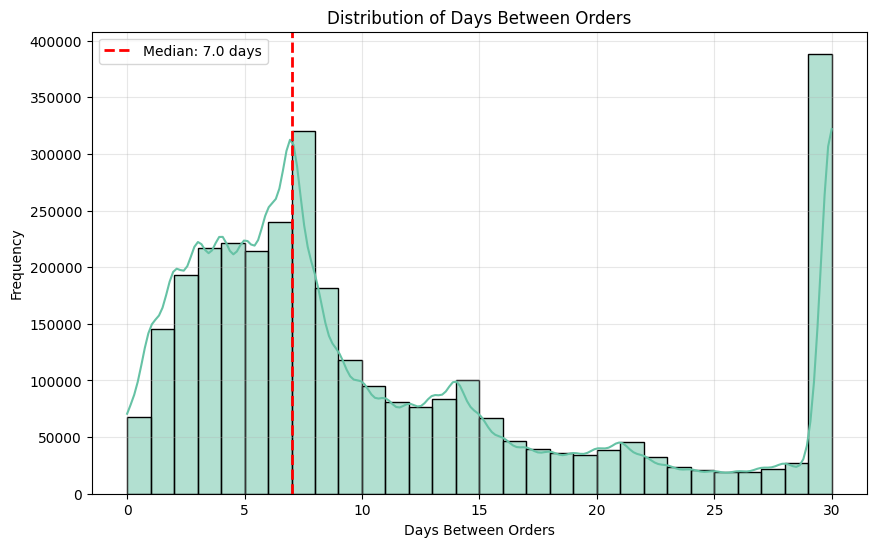

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop missing values
days_gap = orders['days_since_prior_order'].dropna()

plt.figure(figsize=(10,6))
sns.histplot(days_gap, bins=30, kde=True, color='#66c2a5', edgecolor='black')  # histogram + density
plt.axvline(days_gap.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {days_gap.median():.1f} days')
plt.xlabel("Days Between Orders")
plt.ylabel("Frequency")
plt.title("Distribution of Days Between Orders")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation: Distribution of Days Between Orders

**Shape of the Distribution:**
- The distribution **peaks at 7 days** and declines on both sides,
  resembling a roughly bell-shaped curve in its main body
- There is a large **artificial spike at 30 days** caused by Instacart's
  data cap, which distorts the overall shape
- The distribution does not follow a clean skew in either direction due
  to this cap

**Notable Features:**
- **Peak at 7 days** — the most common gap between orders, confirming that
  many customers shop on a **weekly basis**
- **Spike at 30 days** — approximately 380,000 orders recorded at exactly 30 days.
  This is because Instacart **caps `days_since_prior_order` at 30**, meaning any
  gap of 30 days or more is recorded as 30. This is a data limitation, not a
  real customer behaviour pattern.
- **Median of 7.0 days** — confirms that half of all customers reorder
  within a week

**Business Insight:**
- Weekly shopping is the dominant customer behaviour
- The 30-day cap should be considered carefully in any predictive analysis,
  as it may underrepresent infrequent shoppers

##**Step 7 : Distribution of Order Numbers with Density**

This plot shows how often different order numbers happen. The bars show counts  and the curve shows where most orders are so we can see typical order numbers.

Summary of order_number:
count    3.421083e+06
mean     1.715486e+01
std      1.773316e+01
min      1.000000e+00
25%      5.000000e+00
50%      1.100000e+01
75%      2.300000e+01
max      1.000000e+02
Name: order_number, dtype: float64


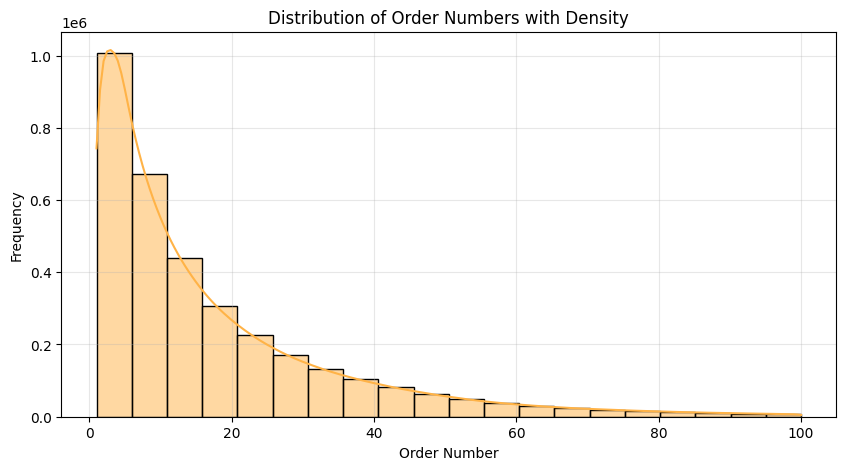

In [4]:
# Summary statistics
print("Summary of order_number:")
print(orders['order_number'].describe())

# Count orders per order_number
order_counts = orders['order_number'].value_counts().sort_index()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(orders['order_number'], bins=20, kde=True, color='#ffb347', edgecolor='black')
plt.xlabel("Order Number")
plt.ylabel("Frequency")
plt.title("Distribution of Order Numbers with Density")
plt.grid(alpha=0.3)
plt.show()

### Interpretation: Distribution of Order Numbers

**Shape of the Distribution:**
- The distribution is clearly **right-skewed**
- It peaks sharply at **order number 5** then drops steeply between 5 and 10
- From order 10 onwards the decline becomes more gradual, flattening
  significantly after order 60 all the way to 100

**Notable Features:**
- **Sharp drop from 5 to 10** — the frequency drops from approximately
  1.0 to 0.6, indicating that many customers do not progress far beyond
  their initial orders
- **Gradual decline from 10 to 60** — frequency continues decreasing
  through 0.4, 0.3, and 0.2, representing a smaller but steady group
  of returning customers
- **Near flat tail from 60 to 100** — a small but consistent group of
  highly loyal customers who order very frequently
- **Median of 11** — half of all orders in the dataset come from customers
  who have placed 11 or fewer orders

**Business Insight:**
- Customer drop-off is steepest in the **early ordering stages (5-10)**
- Retaining customers past their **10th order** is critical, as beyond
  that point they tend to become long-term loyal shoppers
- The flat tail beyond order 60 represents Instacart's most valuable
  repeat customer segment

## **Top 10 Add-to-Cart Positions**
This chart shows the most common positions items are added to the cart. The bars show how many times each position occurs , helping us see which positions are used the most.

Summary of add_to_cart_order:
count    3.243449e+07
mean     8.351076e+00
std      7.126671e+00
min      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.100000e+01
max      1.450000e+02
Name: add_to_cart_order, dtype: float64


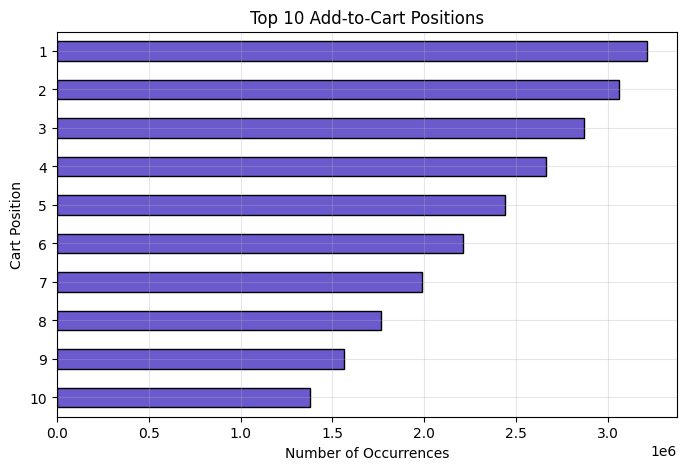

In [5]:
# Summary statistics
print("Summary of add_to_cart_order:")
print(order_products['add_to_cart_order'].describe())

# Top 10 add-to-cart positions
cart_counts = order_products['add_to_cart_order'].value_counts().sort_index()

# Count top 10 add-to-cart positions
top_cart = order_products['add_to_cart_order'].value_counts().head(10).sort_values()

plt.figure(figsize=(8,5))
top_cart.plot(kind='barh', color='#6a5acd', edgecolor='black')
plt.xlabel("Number of Occurrences")
plt.ylabel("Cart Position")
plt.title("Top 10 Add-to-Cart Positions")
plt.grid(alpha=0.3)
plt.show()

### Interpretation: Top 10 Add-to-Cart Positions


The bars decrease gradually from position 1 to position 10, showing that
most products are added to the cart earlier in the shopping process.
As the cart position increases, fewer products are added at those later
stages, meaning customers tend to add their most important or habitual
items first before adding additional products.


## **Step 8:** **Univariate Analysis of a Categorical Variable**

We calculate the frequency counts of the `order_dow` variable to see how many orders occur on each day of the week.

In [6]:
# Step 8: Count orders per day of week
dow_counts = orders['order_dow'].value_counts().sort_index()
dow_counts

,count
order_dow,
0,600905
1,587478
2,467260
3,436972
4,426339
5,453368
6,448761


### Interpretation: Orders by Day of Week

| Day | Order Count |
|-----|-------------|
| 0 (Sunday) | 600,905 |
| 1 (Monday) | 587,478 |
| 2 (Tuesday) | 467,260 |
| 3 (Wednesday) | 436,972 |
| 4 (Thursday) | 426,339 |
| 5 (Friday) | 453,368 |
| 6 (Saturday) | 448,761 |

**Key Observations:**
- **Sunday (0) and Monday (1)** are the busiest days for orders
- **Thursday (4)** has the fewest orders
- Midweek days (Tuesday to Thursday) are consistently lower than
  weekend days
- This aligns with expectations as people tend to grocery shop
  at the start of the week or on weekends

### **Step 9: Orders by Day of the Week - Bar Chart**


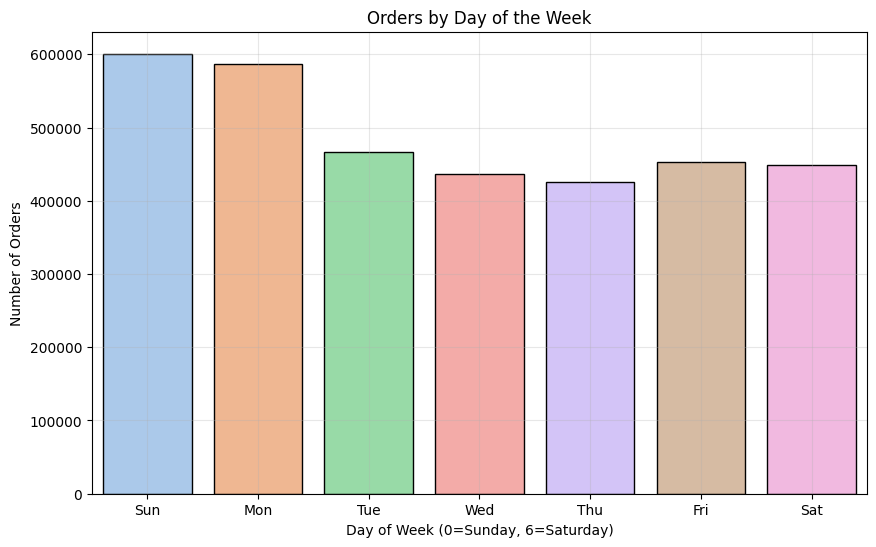

Figure saved successfully ✅


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create figures folder if it doesn't exist
os.makedirs("/content/drive/MyDrive/ADA2026_Instacart_Project/outputs/figures/", exist_ok=True)

# Recreate dow_counts
dow_counts = orders['order_dow'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=dow_counts.index, y=dow_counts.values, hue=dow_counts.index,
            palette='pastel', edgecolor='black', legend=False)
plt.xlabel("Day of Week (0=Sunday, 6=Saturday)")
plt.ylabel("Number of Orders")
plt.title("Orders by Day of the Week")
plt.xticks(ticks=range(7), labels=['Sun','Mon','Tue','Wed','Thu','Fri','Sat'])
plt.grid(alpha=0.3)

# Save to Google Drive
plt.savefig("/content/drive/MyDrive/ADA2026_Instacart_Project/outputs/figures/orders_by_day.png", bbox_inches='tight')

plt.show()
print("Figure saved successfully ✅")

### Interpretation: Orders by Day of the Week

- **Sunday** has the highest number of orders, making it the busiest
  shopping day of the week
- **Thursday** has the fewest orders, though the difference between
  Thursday and Wednesday is very slight
- There is a noticeable drop between **Monday and Tuesday**, suggesting
  customers are significantly less active from Tuesday onwards
- The remaining days (Tuesday, Wednesday, Thursday, Friday, Saturday)
  are relatively close in order counts with small differences between them

**Business Insight:**
- Instacart could target **Sunday and Monday** for promotions and
  marketing campaigns when customer activity is highest
- **Midweek promotions** could help boost orders on slower days like
  Wednesday and Thursday

##**Step 10: Saving the Figure Before Displaying**  

The bar chart was saved using `plt.savefig()` before calling `plt.show()`.
This ensures the figure is correctly saved to the `outputs/figures/` folder,
because displaying the plot with `plt.show()` closes the figure in Colab,
which would prevent it from being saved afterwards.

## **Step 11: Interpretation**

1. **Most evident patterns:** Orders are highest on Sunday (0) and Monday (1)
   and lower on the other days of the week, suggesting customers prefer to
   shop at the start of the week.

2. **Surprises:** The drop in orders mid-week (Tuesday–Thursday) was unexpected,
   as one might assume orders would be more evenly spread across the week or
   peak on weekends when people have more free time.

3. **Important variables for further analysis:**
   - `order_dow` — to understand weekly ordering trends
   - `order_number` — to analyze customer loyalty and engagement levels
   - `days_since_prior_order` — to analyze customer frequency and repeat behaviour